Number of target rows/dates used: 1657
Date range: 1980-06-01 00:00:00 to 2024-09-28 00:00:00
Saved figure to ../figures/mechanism_composites/raw_mean_fields_on_p95_wbt_days.png


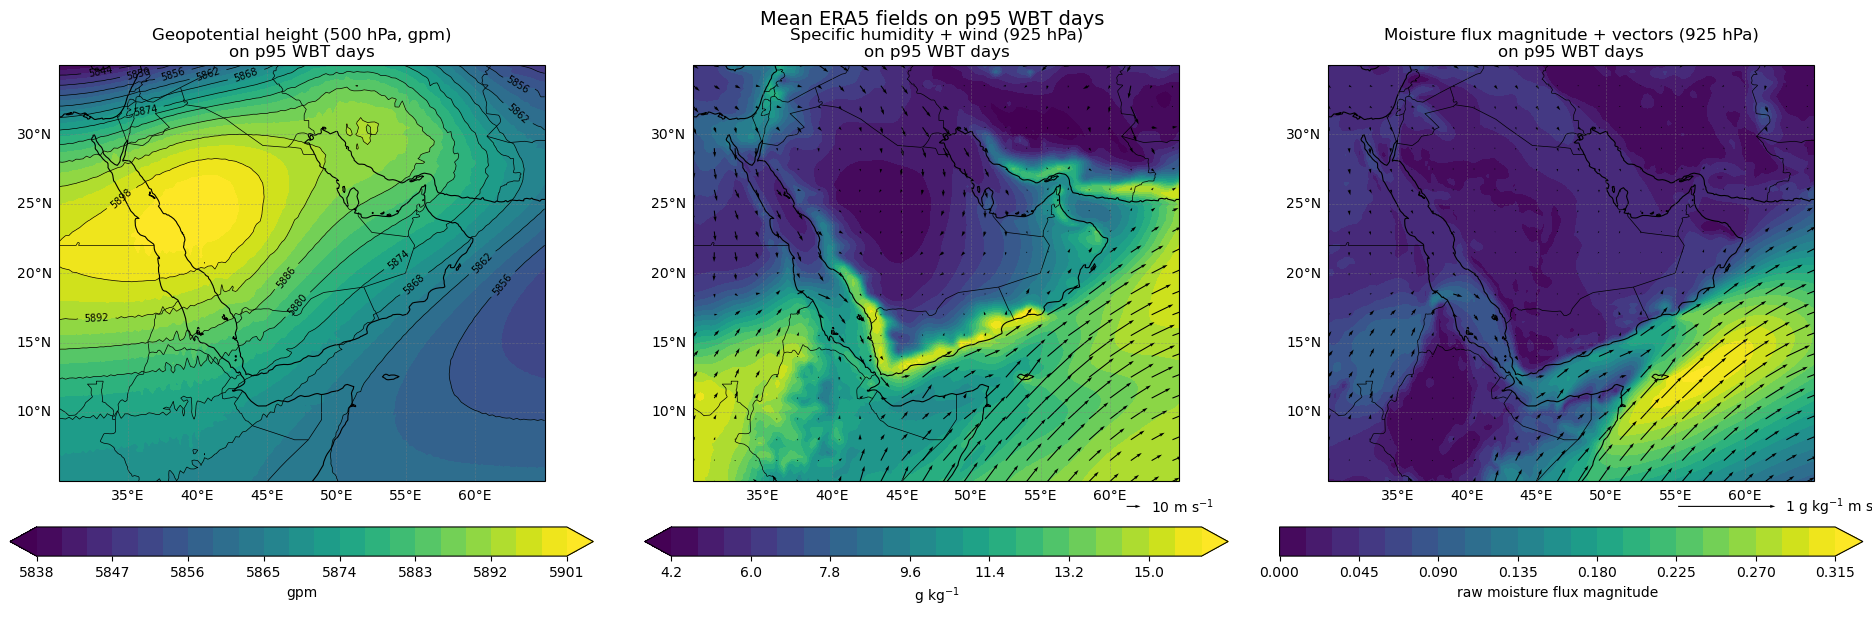

In [10]:
#!/usr/bin/env python3

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# ============================================================
# Paths
# ============================================================
ERA5_ROOT = Path("../data/era5")
DERIVED_ROOT = Path("../data/era5_derived")
EVENT_CSV = Path("../data/wbt_sst_city_runs/city_daily_wbt_JJAS_with_lagged_phases.csv")
FIG_DIR = Path("../figures/mechanism_composites")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# User settings
# ============================================================
OUTFILE = FIG_DIR / "raw_mean_fields_on_p95_wbt_days.png"

# If True, each date is used once even if multiple cities exceed p95 on that day.
# This is usually the better choice for a regional composite.
UNIQUE_DATES_ONLY = True

# Optional city filter:
# CITY = None
# CITY = "dubai"
# CITY = ["dubai", "abu_dhabi", "doha"]
CITY = None

# Pressure levels to use if a pressure-level dimension exists
GEOPOTENTIAL_LEVEL = 500   # hPa
LOWER_LEVEL = 925          # hPa for q, u, v, moisture flux

# Plotting settings
ARROW_STRIDE = 6
WIND_ARROW_SCALE = 350
MFLUX_ARROW_SCALE = 5
FIG_DPI = 300

# Region (set to None to use full data extent)
REGION = {
    "lon_min": 30,
    "lon_max": 65,
    "lat_min": 5,
    "lat_max": 35,
}

# ============================================================
# Variable file locations
# ============================================================
VAR_PATHS = {
    "geopotential": ERA5_ROOT / "geopotential",
    "specific_humidity": ERA5_ROOT / "specific_humidity",
    "u_component_of_wind": ERA5_ROOT / "u_component_of_wind",
    "v_component_of_wind": ERA5_ROOT / "v_component_of_wind",
    "moisture_flux_u_925": DERIVED_ROOT / "moisture_flux_u_925",
    "moisture_flux_v_925": DERIVED_ROOT / "moisture_flux_v_925",
    "moisture_flux_mag_925": DERIVED_ROOT / "moisture_flux_mag_925",
}

FILE_RE = re.compile(r".*_(\d{4})_(\d{2})\.nc$")
G = 9.80665

# ============================================================
# Helpers
# ============================================================
def get_var_name(ds: xr.Dataset) -> str:
    if len(ds.data_vars) != 1:
        raise ValueError(f"Expected 1 variable, got {list(ds.data_vars)}")
    return list(ds.data_vars)[0]


def parse_year_month(path: Path):
    m = FILE_RE.match(path.name)
    if not m:
        raise ValueError(f"Could not parse year/month from {path.name}")
    return int(m.group(1)), int(m.group(2))


def find_coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords or c in ds.dims:
            return c
    return None


def normalize_lat_lon(ds: xr.Dataset) -> xr.Dataset:
    lat_name = find_coord_name(ds, ["latitude", "lat"])
    lon_name = find_coord_name(ds, ["longitude", "lon"])

    rename_map = {}
    if lat_name and lat_name != "latitude":
        rename_map[lat_name] = "latitude"
    if lon_name and lon_name != "longitude":
        rename_map[lon_name] = "longitude"

    if rename_map:
        ds = ds.rename(rename_map)

    if "longitude" in ds.coords:
        lon = ds["longitude"]
        if lon.max() > 180:
            ds = ds.assign_coords(longitude=((lon + 180) % 360) - 180).sortby("longitude")

    if "latitude" in ds.coords:
        ds = ds.sortby("latitude")

    return ds


def subset_region(da: xr.DataArray) -> xr.DataArray:
    if REGION is None:
        return da

    if "latitude" in da.coords:
        lat0 = REGION["lat_min"]
        lat1 = REGION["lat_max"]
        if da["latitude"][0] < da["latitude"][-1]:
            da = da.sel(latitude=slice(lat0, lat1))
        else:
            da = da.sel(latitude=slice(lat1, lat0))

    if "longitude" in da.coords:
        da = da.sel(longitude=slice(REGION["lon_min"], REGION["lon_max"]))

    return da


def open_dataarray(path: Path) -> xr.DataArray:
    ds = xr.open_dataset(path)
    ds = normalize_lat_lon(ds)
    var = get_var_name(ds)
    da = ds[var]

    if "time" not in da.dims:
        raise ValueError(f"'time' not found in {path}")

    return da.sortby("time")


def maybe_select_level(da: xr.DataArray, target_level: int) -> xr.DataArray:
    level_name = find_coord_name(
        da.to_dataset(name="tmp"),
        ["pressure_level", "level", "isobaricInhPa", "plev"]
    )
    if level_name is None:
        return da

    coord_vals = da[level_name].values
    if target_level in coord_vals:
        return da.sel({level_name: target_level})
    else:
        raise ValueError(
            f"Requested level {target_level} not found. "
            f"Available levels: {coord_vals}"
        )


def collect_target_dates(event_csv: Path) -> pd.DatetimeIndex:
    df = pd.read_csv(event_csv, parse_dates=["time"])

    if CITY is not None:
        if isinstance(CITY, str):
            city_list = [CITY]
        else:
            city_list = CITY
        df = df[df["city"].isin(city_list)].copy()

    if "exceed_p95" not in df.columns:
        raise ValueError("'exceed_p95' column not found in event CSV")

    df = df[df["exceed_p95"] == 1].copy()

    if df.empty:
        raise ValueError("No p95 exceedance days found after filtering.")

    df["date"] = pd.to_datetime(df["time"]).dt.floor("D")

    # --------------------------------------------------
    # Restrict to dates where ERA5 predictor fields exist
    # --------------------------------------------------
    df = df[df["date"] >= pd.Timestamp("1980-01-01")].copy()

    if df.empty:
        raise ValueError("No p95 exceedance days remain on/after 1980-01-01.")

    if UNIQUE_DATES_ONLY:
        dates = pd.DatetimeIndex(sorted(df["date"].drop_duplicates()))
    else:
        dates = pd.DatetimeIndex(sorted(df["date"]))

    return dates


def monthly_files_for_dates(var_dir: Path, dates: pd.DatetimeIndex):
    ym = sorted(set((d.year, d.month) for d in dates))
    files = []
    for year, month in ym:
        pattern = f"*_{year}_{month:02d}.nc"
        matches = sorted(var_dir.glob(pattern))
        if not matches:
            raise FileNotFoundError(f"No file matched {pattern} in {var_dir}")
        if len(matches) > 1:
            print(f"Warning: multiple matches for {pattern}, using {matches[0].name}")
        files.append(matches[0])
    return files


def composite_mean_for_dates(var_dir: Path, dates: pd.DatetimeIndex, level=None) -> xr.DataArray:
    files = monthly_files_for_dates(var_dir, dates)
    dates_np = dates.values.astype("datetime64[ns]")

    pieces = []
    for fp in files:
        
        da = open_dataarray(fp)

        if level is not None:
            da = maybe_select_level(da, level)

        da = subset_region(da)

        this_times = np.intersect1d(
            da["time"].values.astype("datetime64[ns]"),
            dates_np
        )

        if len(this_times) == 0:
            continue

        pieces.append(da.sel(time=this_times))

    if not pieces:
        raise ValueError(f"No matching times found for {var_dir}")

    full = xr.concat(pieces, dim="time").sortby("time")
    return full.mean("time", skipna=True)


def setup_map(ax, extent=None):
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.95", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)

    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.MultipleLocator(5)
    gl.ylocator = mticker.MultipleLocator(5)
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()


def quiver_subsample(lon, lat, u, v, stride):
    return (
        lon[::stride],
        lat[::stride],
        u[::stride, ::stride],
        v[::stride, ::stride],
    )


# ============================================================
# Main
# ============================================================
def main():
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    dates = collect_target_dates(EVENT_CSV)
    print(f"Number of target rows/dates used: {len(dates)}")
    print(f"Date range: {dates.min()} to {dates.max()}")

    # --- composites ---
    z = composite_mean_for_dates(
        VAR_PATHS["geopotential"], dates, level=GEOPOTENTIAL_LEVEL
    ) / G
    z = z.rename("z_gpm")

    q = composite_mean_for_dates(
        VAR_PATHS["specific_humidity"], dates, level=LOWER_LEVEL
    ) * 1000.0
    q = q.rename("q_gkg")

    u = composite_mean_for_dates(
        VAR_PATHS["u_component_of_wind"], dates, level=LOWER_LEVEL
    )
    v = composite_mean_for_dates(
        VAR_PATHS["v_component_of_wind"], dates, level=LOWER_LEVEL
    )

    mfu = composite_mean_for_dates(VAR_PATHS["moisture_flux_u_925"], dates)
    mfv = composite_mean_for_dates(VAR_PATHS["moisture_flux_v_925"], dates)
    mfm = composite_mean_for_dates(VAR_PATHS["moisture_flux_mag_925"], dates)

    # --- coordinate handling ---
    lon = z["longitude"].values
    lat = z["latitude"].values
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]

    # ensure other fields align
    q = q.interp(latitude=z.latitude, longitude=z.longitude)
    u = u.interp(latitude=z.latitude, longitude=z.longitude)
    v = v.interp(latitude=z.latitude, longitude=z.longitude)
    mfu = mfu.interp(latitude=z.latitude, longitude=z.longitude)
    mfv = mfv.interp(latitude=z.latitude, longitude=z.longitude)
    mfm = mfm.interp(latitude=z.latitude, longitude=z.longitude)

    # --- figure ---
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(19, 5.8),
        subplot_kw={"projection": proj},
        constrained_layout=True,
    )

    # Panel 1: geopotential height
    ax = axes[0]
    setup_map(ax, extent=extent)
    cf1 = ax.contourf(
        z["longitude"],
        z["latitude"],
        z,
        levels=21,
        transform=proj,
        extend="both",
    )
    cs1 = ax.contour(
        z["longitude"],
        z["latitude"],
        z,
        levels=12,
        colors="k",
        linewidths=0.5,
        transform=proj,
    )
    ax.clabel(cs1, fmt="%d", fontsize=7)
    ax.set_title(f"Geopotential height ({GEOPOTENTIAL_LEVEL} hPa, gpm)\non p95 WBT days")

    cbar1 = fig.colorbar(cf1, ax=ax, orientation="horizontal", pad=0.05, shrink=0.95)
    cbar1.set_label("gpm")

    # Panel 2: q with wind
    ax = axes[1]
    setup_map(ax, extent=extent)
    cf2 = ax.contourf(
        q["longitude"],
        q["latitude"],
        q,
        levels=21,
        transform=proj,
        extend="both",
    )

    qlon, qlat, qu, qv = quiver_subsample(
        q["longitude"].values,
        q["latitude"].values,
        u.values,
        v.values,
        ARROW_STRIDE,
    )
    qv_plot = ax.quiver(
        qlon,
        qlat,
        qu,
        qv,
        transform=proj,
        scale=WIND_ARROW_SCALE,
        width=0.0022,
    )
    ax.quiverkey(qv_plot, 0.92, -0.06, 10, "10 m s$^{-1}$", labelpos="E")
    ax.set_title(f"Specific humidity + wind ({LOWER_LEVEL} hPa)\non p95 WBT days")

    cbar2 = fig.colorbar(cf2, ax=ax, orientation="horizontal", pad=0.05, shrink=0.95)
    cbar2.set_label("g kg$^{-1}$")

    # Panel 3: moisture flux magnitude with arrows
    ax = axes[2]
    setup_map(ax, extent=extent)
    cf3 = ax.contourf(
        mfm["longitude"],
        mfm["latitude"],
        mfm,
        levels=21,
        transform=proj,
        extend="max",
    )

    mlon, mlat, qmu, qmv = quiver_subsample(
        mfm["longitude"].values,
        mfm["latitude"].values,
        mfu.values,
        mfv.values,
        ARROW_STRIDE,
    )
    qv_plot2 = ax.quiver(
        mlon,
        mlat,
        qmu,
        qmv,
        transform=proj,
        scale=MFLUX_ARROW_SCALE,
        width=0.0022,
    )
    ax.quiverkey(qv_plot2, 0.92, -0.06, 1, "1 g kg$^{-1}$ m s$^{-1}$ ", labelpos="E")
    ax.set_title(f"Moisture flux magnitude + vectors ({LOWER_LEVEL} hPa)\non p95 WBT days")

    cbar3 = fig.colorbar(cf3, ax=ax, orientation="horizontal", pad=0.05, shrink=0.95)
    cbar3.set_label("raw moisture flux magnitude")

    city_txt = "All cities" if CITY is None else f"Cities: {CITY}"
    dedupe_txt = "unique exceedance dates" if UNIQUE_DATES_ONLY else "all exceedance rows"
    fig.suptitle(
        f"Mean ERA5 fields on p95 WBT days",
        y=1.02,
        fontsize=14,
    )

    fig.savefig(OUTFILE, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved figure to {OUTFILE}")


if __name__ == "__main__":
    main()